# KDD Part 2 - Obada

# 1. Importing libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Loading and Exploring

In [2]:
df = pd.read_csv(r'Ecommerce Customers.csv')

In [3]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB
None


In [6]:
# of records & features
print("# of records : ",df.shape[0])
print("# of features : ", df.shape[1])

# of records :  500
# of features :  8


### ------------- Check Null values -------------

In [7]:
# Check datatypes and missing values
print(df.isnull().sum())

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


# 3. Basic Data cleaning

### ------------- delete duplicate -------------

In [8]:
df.drop_duplicates(inplace=True)

### ------------- drop useless columns -------------


In [9]:
df.drop(columns="Email",inplace=True)
df.drop(columns="Address",inplace=True)

### --------- Prepare Target Column ---------


In [10]:
# the taget is "Yearly Amount Spent" column"
df["y"] = df["Yearly Amount Spent"]
df.drop(columns="Yearly Amount Spent",inplace=True)

### --------- feature engineering ---------

In [11]:
df["App_Web_Ratio"] = df["Time on App"] / (df["Time on Website"] + 1e-6)
df["Total_Time"] = df["Time on App"] + df["Time on Website"]

# 4. Correlation

In [12]:
corr = df.corr(numeric_only=True)
corr['y'].sort_values(ascending=False)
abs(corr['y']).sort_values(ascending=False)

y                       1.000000
Length of Membership    0.809084
Time on App             0.499328
App_Web_Ratio           0.487301
Avg. Session Length     0.355088
Total_Time              0.334801
Time on Website         0.002641
Name: y, dtype: float64

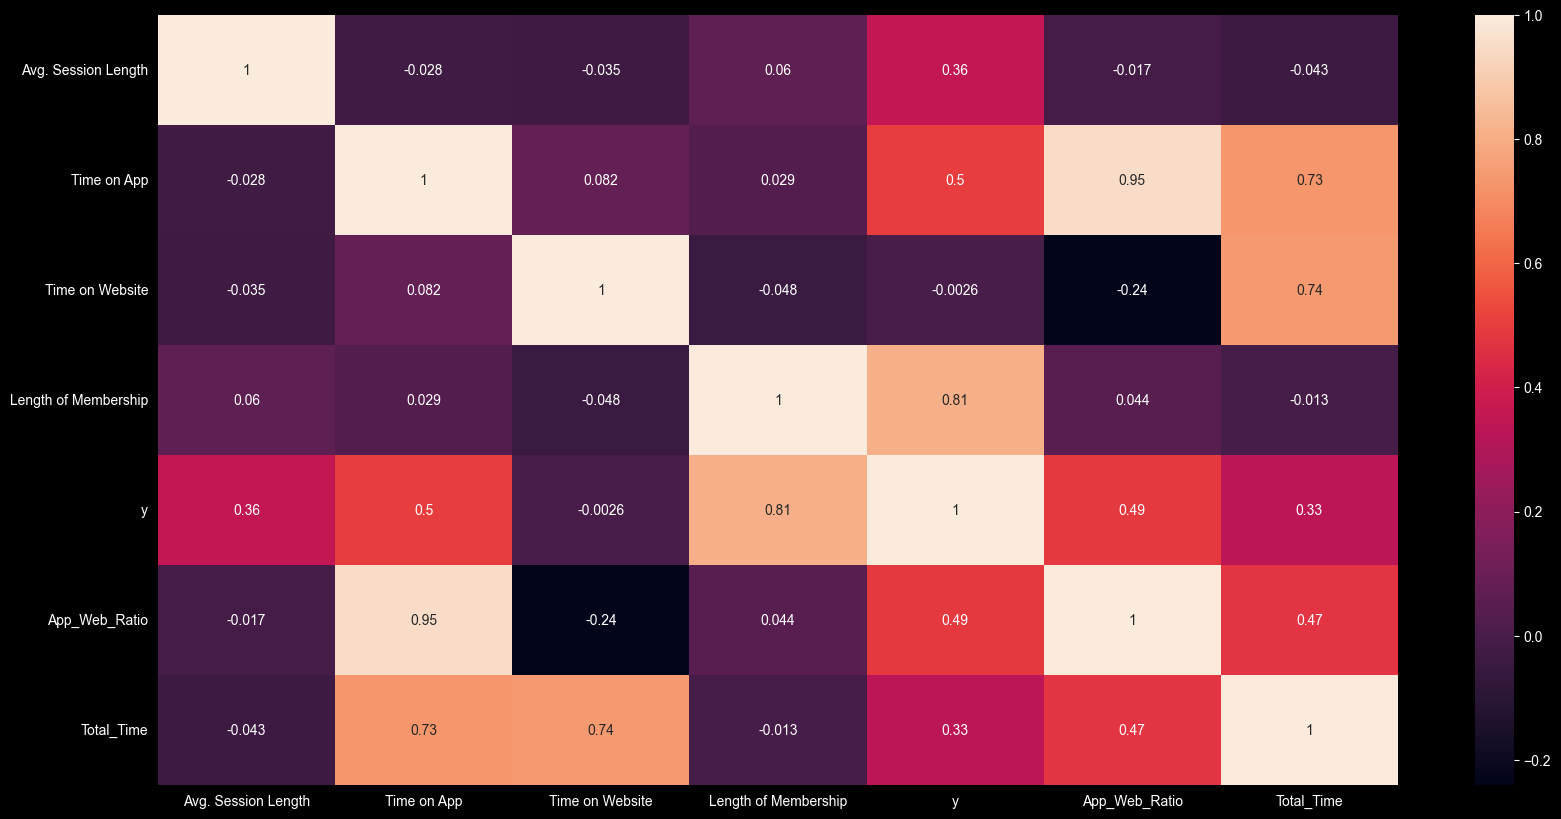

In [13]:
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True)
plt.show()

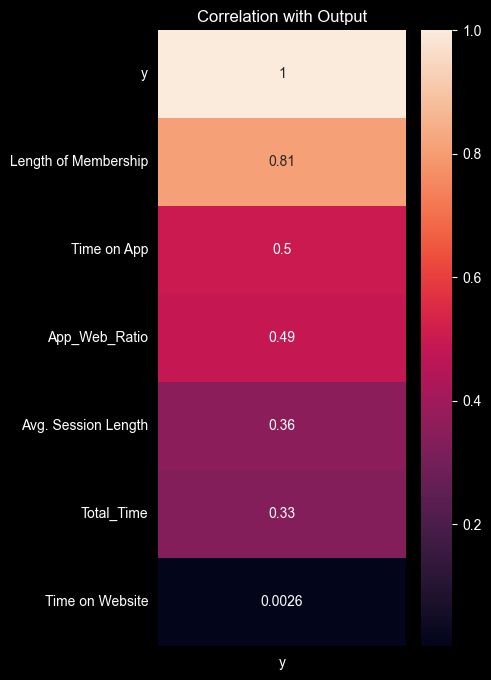

In [14]:
corr_matrix = df.select_dtypes(include=['number']).corr()
output_corr = corr_matrix[['y']].abs().sort_values(by='y', ascending=False)

plt.figure(figsize=(4, 8))
sns.heatmap(output_corr, annot=True)
plt.title('Correlation with Output')
plt.show()

# 4. Data Visualization

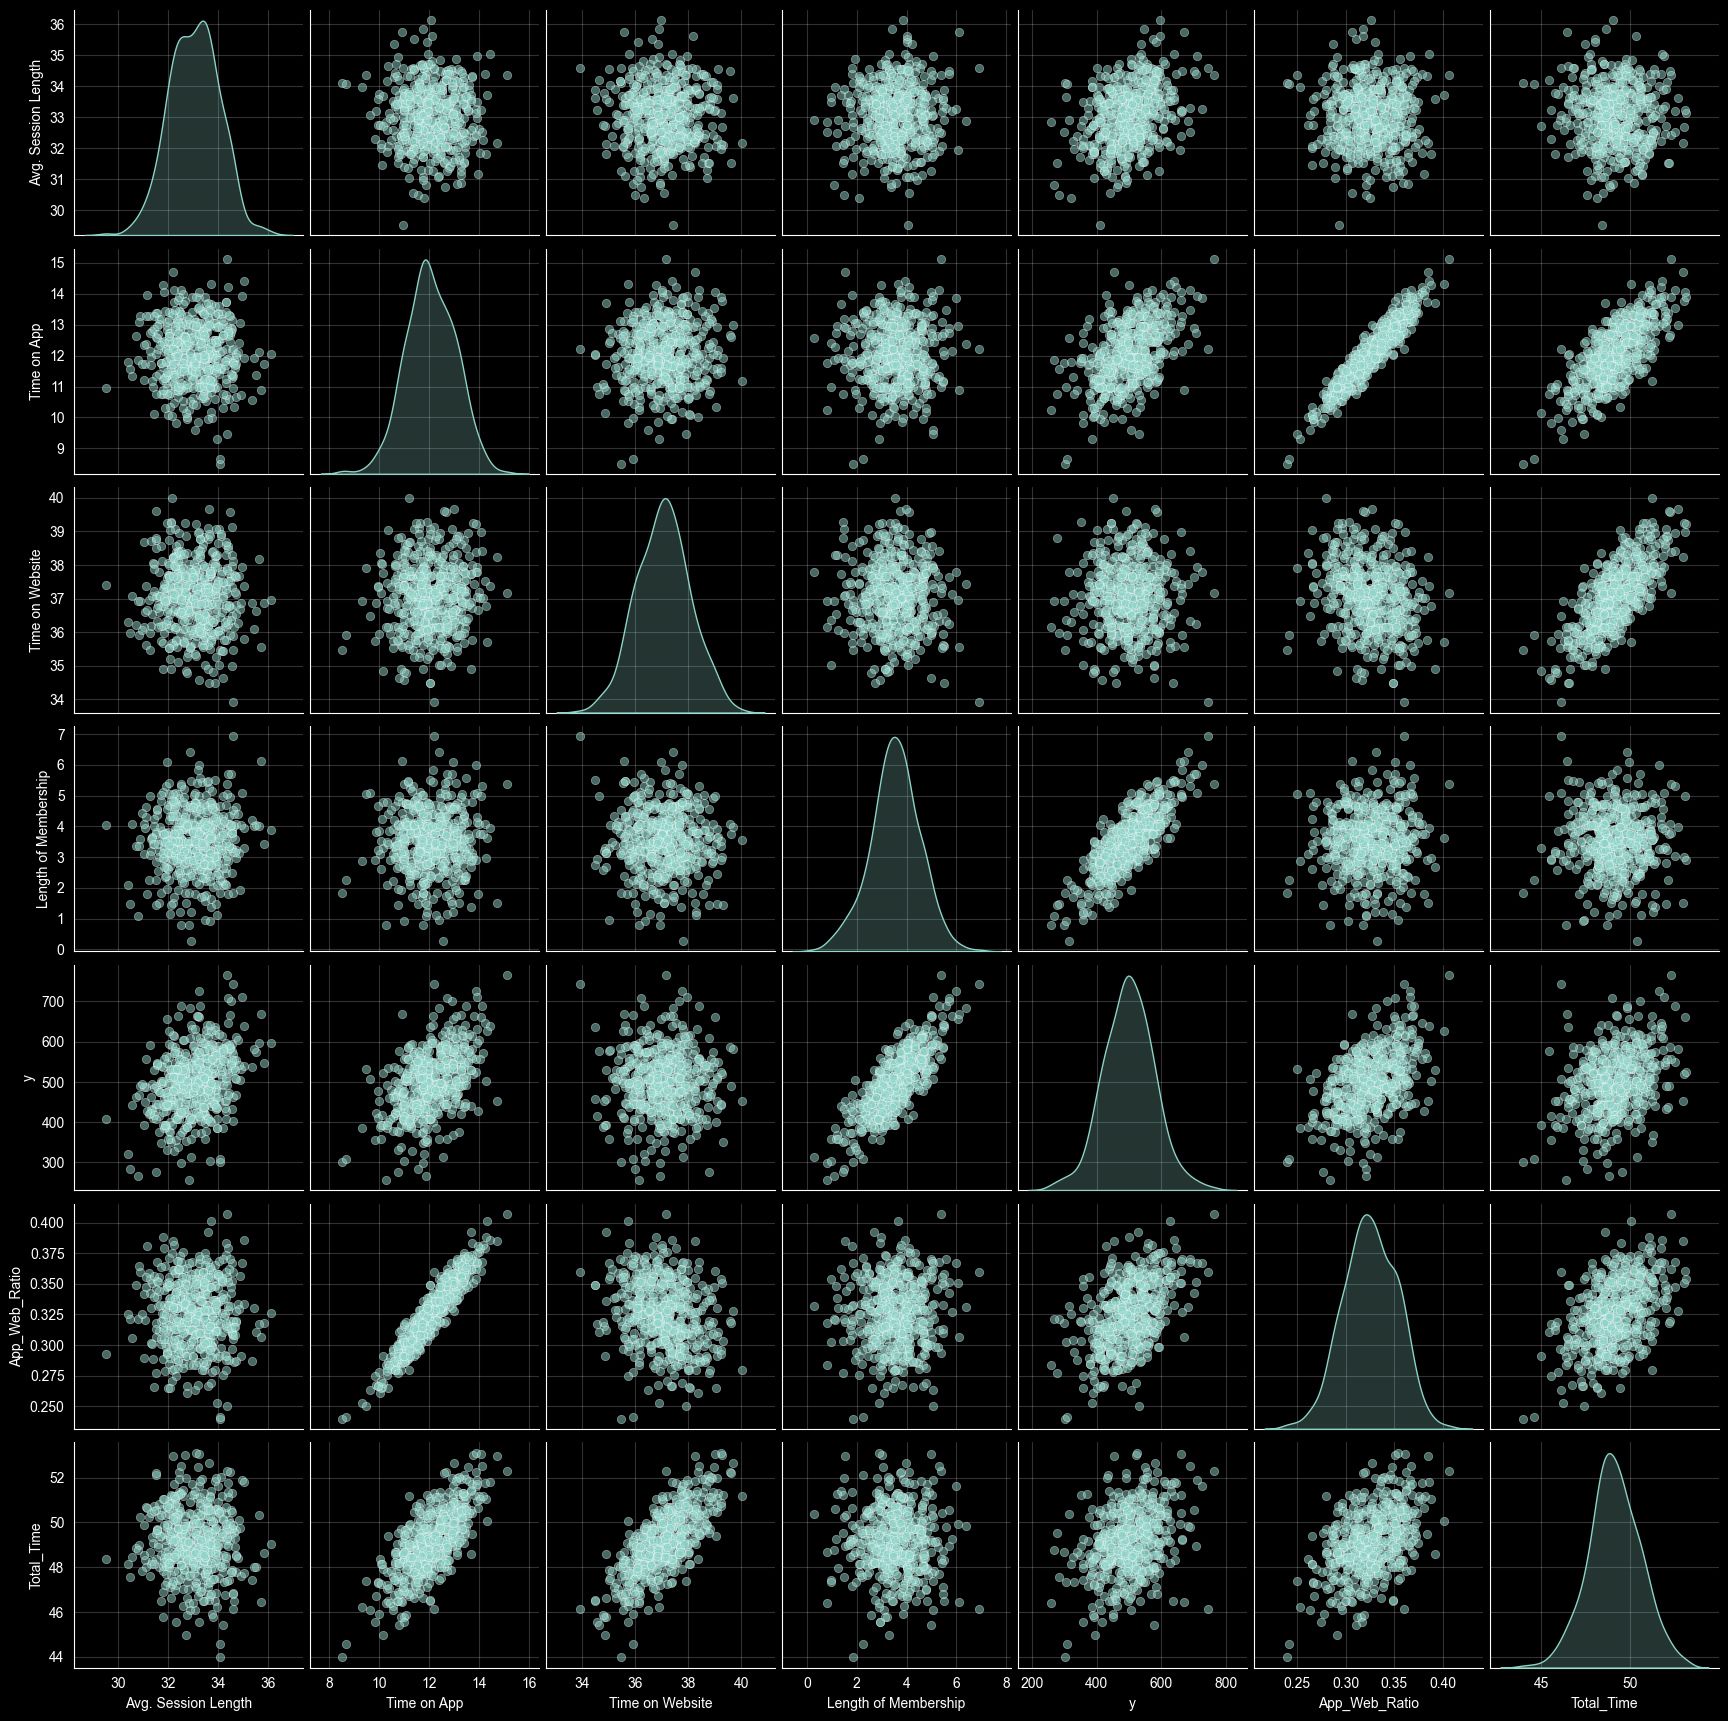

In [15]:
plt.style.use("dark_background")
g = sns.pairplot(
    data=df,
    diag_kind="kde",
    plot_kws={"alpha": 0.5}
)
# Change grid transparency
for ax in g.axes.flatten():
    if ax is not None:
        ax.grid(True, alpha=0.2)  # Change alpha here
plt.show()

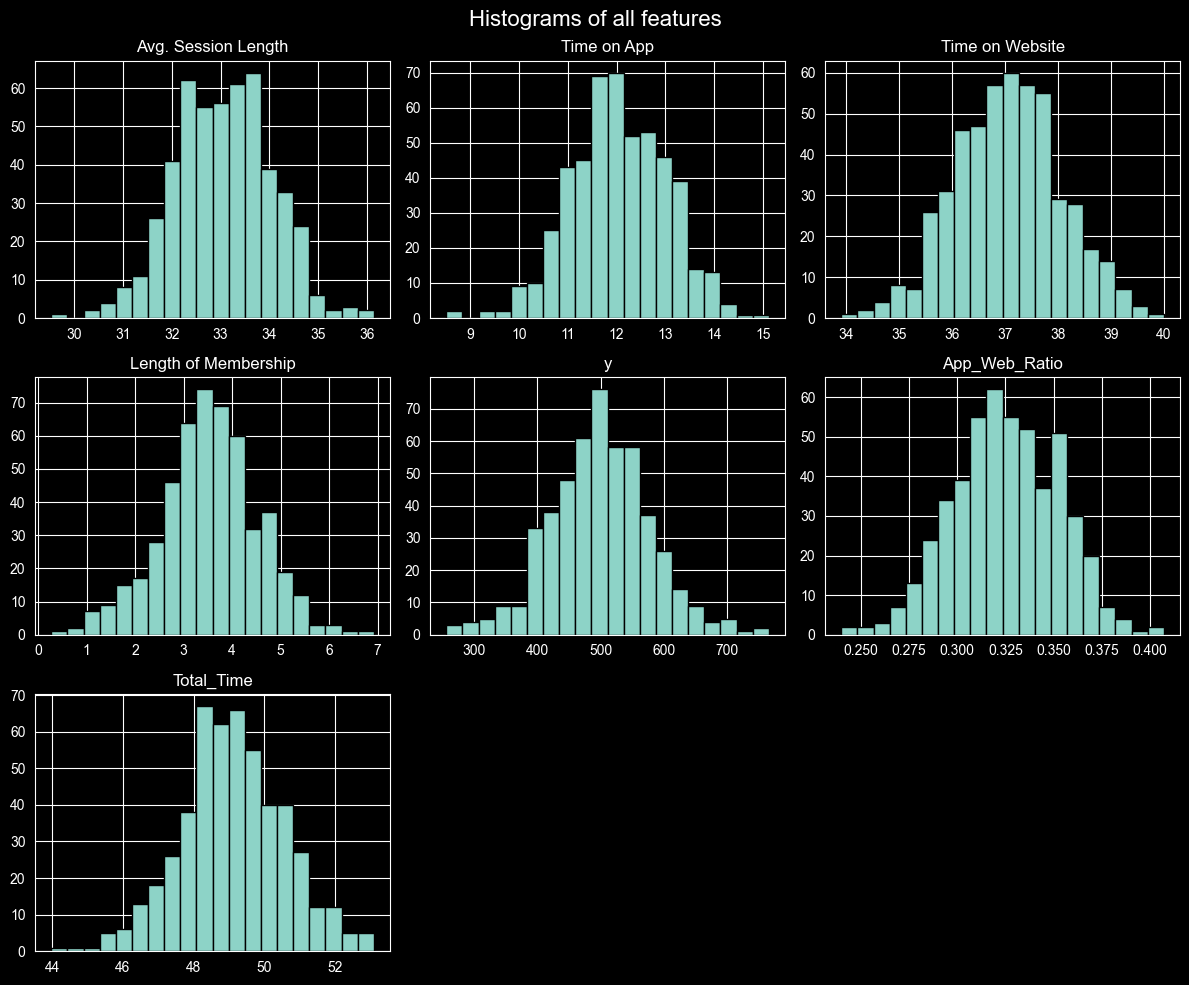

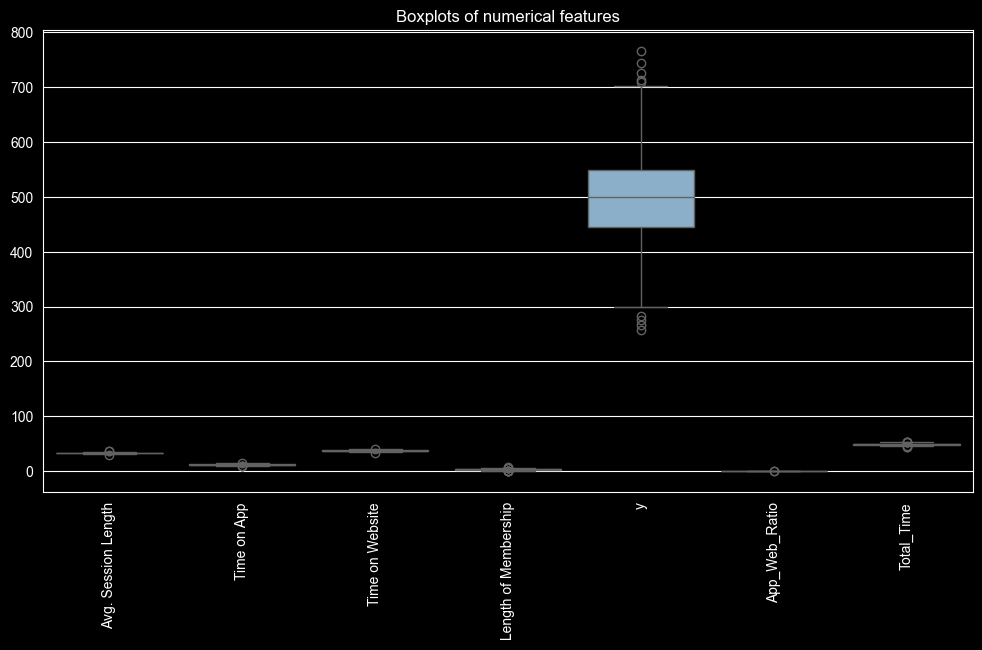

In [16]:
# توزيع كل سمة رقمية
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Histograms of all features", size=16)
plt.tight_layout()
plt.show()

#للكشف عن القيم الشاذة (outliers)
plt.figure(figsize=(12, 6))
sns.boxplot(data= df.select_dtypes(include=['int64', 'float64']))
plt.xticks(rotation=90)
plt.title("Boxplots of numerical features")
plt.show()


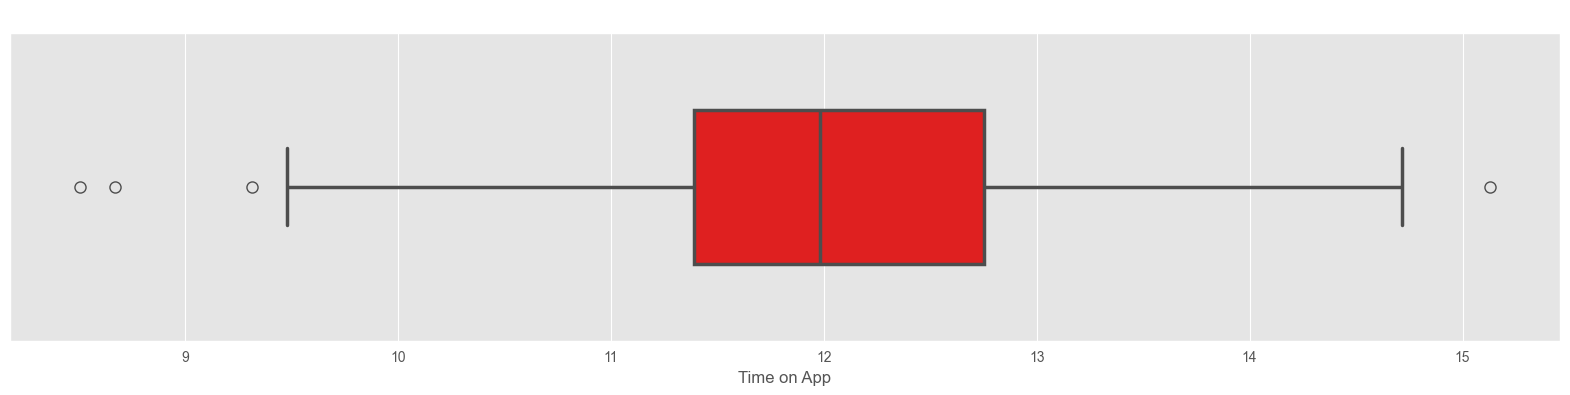

In [138]:
# Outlier Detection for 'Time on App'
plt.style.use('ggplot')
plt.figure(figsize=(20, 4))
sns.boxplot(
    x=df['Time on App'],
    color='red',       # The fill color of the box
    linewidth=2.5,         # Thickness of all lines (box, whiskers, etc.)
    fliersize=8,           # Size of the outlier points
    width=0.5              # Thickness/height of the box itself
)
plt.title('Seaborn Customized Boxplot')
plt.show()

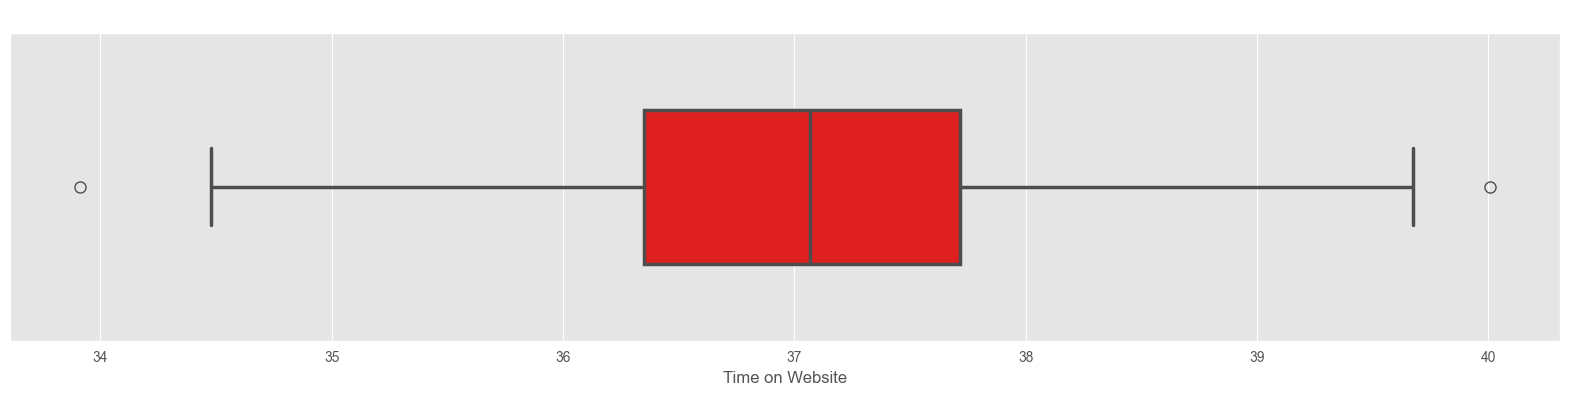

In [139]:
plt.show()
# Outlier Detection for 'Time on App'
plt.style.use('ggplot')
plt.figure(figsize=(20, 4))
sns.boxplot(
    x=df['Time on Website'],
    color='red',  # The fill color of the box
    linewidth=2.5,  # Thickness of all lines (box, whiskers, etc.)
    fliersize=8,  # Size of the outlier points
    width=0.5  # Thickness/height of the box itself
)
plt.title('Seaborn Customized Boxplot')
plt.show()

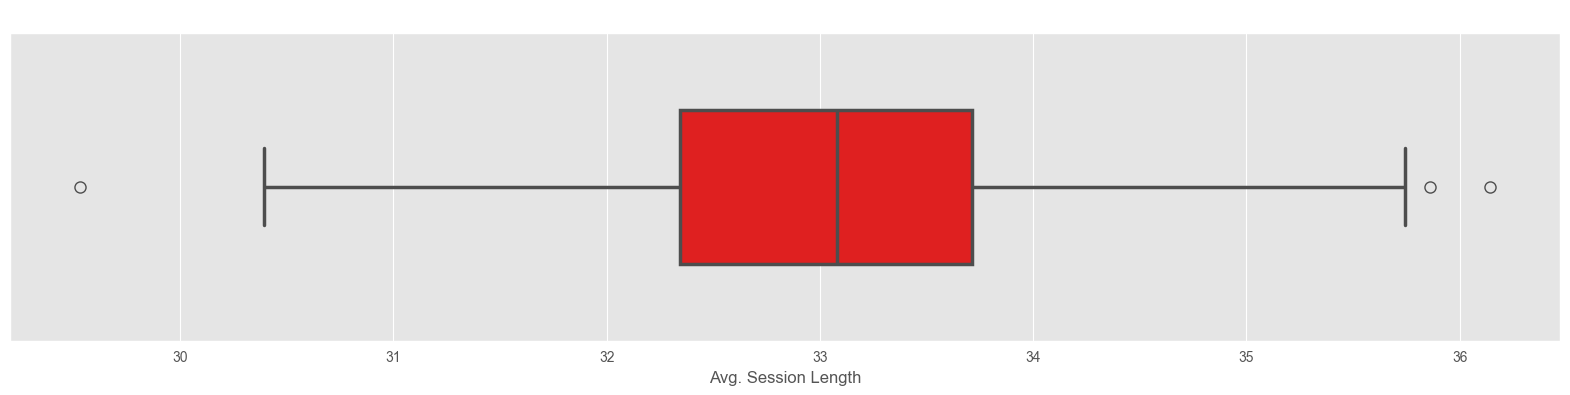

In [140]:
plt.show()
# Outlier Detection for 'Time on App'
plt.style.use('ggplot')
plt.figure(figsize=(20, 4))
sns.boxplot(
    x=df['Avg. Session Length'],
    color='red',  # The fill color of the box
    linewidth=2.5,  # Thickness of all lines (box, whiskers, etc.)
    fliersize=8,  # Size of the outlier points
    width=0.5  # Thickness/height of the box itself
)
plt.title('Seaborn Customized Boxplot')
plt.show()

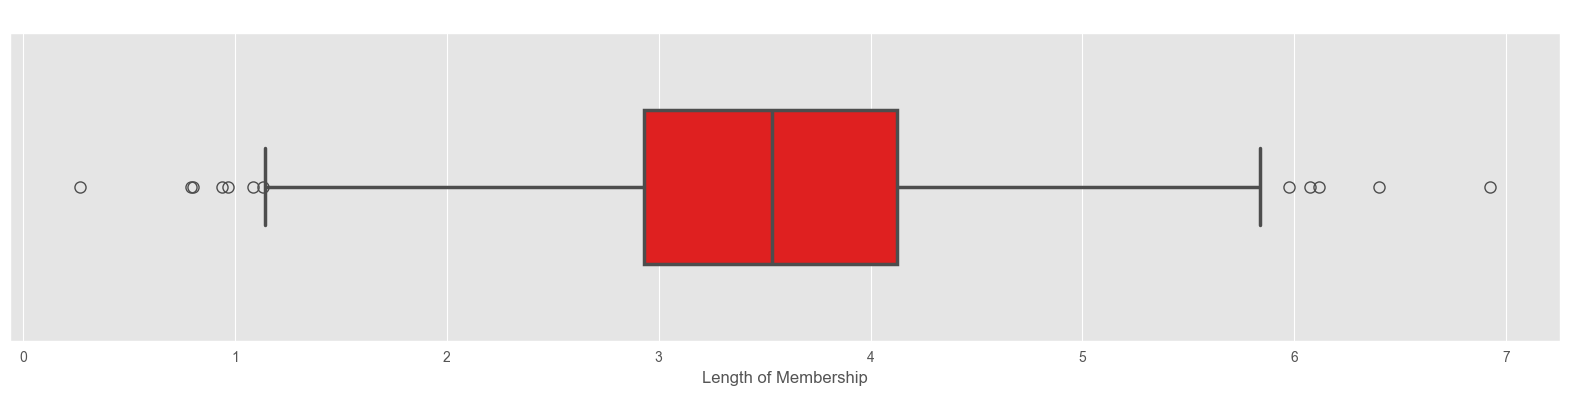

In [141]:
plt.show()
# Outlier Detection for 'Time on App'
plt.style.use('ggplot')
plt.figure(figsize=(20, 4))
sns.boxplot(
    x=df['Length of Membership'],
    color='red',  # The fill color of the box
    linewidth=2.5,  # Thickness of all lines (box, whiskers, etc.)
    fliersize=8,  # Size of the outlier points
    width=0.5  # Thickness/height of the box itself
)
plt.title('Seaborn Customized Boxplot')
plt.show()

## Remove outlier using IQR algorithm for the "Length of Membership"

In [142]:
Q1 = df['Length of Membership'].quantile(0.25)
Q3 = df['Length of Membership'].quantile(0.75)

IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"lower limit: {lower_limit}, upper limit: {upper_limit}")

lower limit: 1.136371357955959, upper limit: 5.920580296370714


In [143]:
# remove the rows in the range
df = df[(df['Length of Membership'] >= lower_limit) & (df['Length of Membership'] <= upper_limit)]

In [144]:
df.shape

(488, 8)

# 5. Encoding Categorical Data

In [145]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Avatar']
df = df.copy()  # ensure no view issues
for col in categorical_cols:
    le = LabelEncoder()
    df.loc[:, col] = le.fit_transform(df[col])

In [146]:
df

,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,y,App_Web_Ratio,Total_Time
0,132,34.497268,12.655651,39.577668,4.082621,587.951054,0.319767,52.233319
1,25,31.926272,11.109461,37.268959,2.664034,392.204933,0.298089,48.378420
2,6,33.000915,11.330278,37.110597,4.104543,487.547505,0.305311,48.440875
3,114,34.305557,13.717514,36.721283,3.120179,581.852344,0.373558,50.438796
4,80,33.330673,12.795189,37.536653,4.446308,599.406092,0.340872,50.331842
...,...,...,...,...,...,...,...,...
495,127,33.237660,13.566160,36.417985,3.746573,573.847438,0.372513,49.984144
496,104,34.702529,11.695736,37.190268,3.576526,529.049004,0.314484,48.886004
497,18,32.646777,11.499409,38.332576,4.958264,551.620145,0.299991,49.831985
498,128,33.322501,12.391423,36.840086,2.336485,456.469510,0.336357,49.231509


# 6. Train - Test Split

In [147]:
from sklearn.model_selection import train_test_split

X = df.drop(['y'], axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Scaling

In [148]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Training Linear Regression Model

In [149]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [150]:
model.coef_

array([ 0.21247197, 25.09946651,  4.38510416,  4.89616826, 57.953484  ,
       30.87619592,  6.43009244])

In [151]:
model.intercept_

np.float64(498.4577274763188)

In [152]:
y_pred = model.predict(X_test)

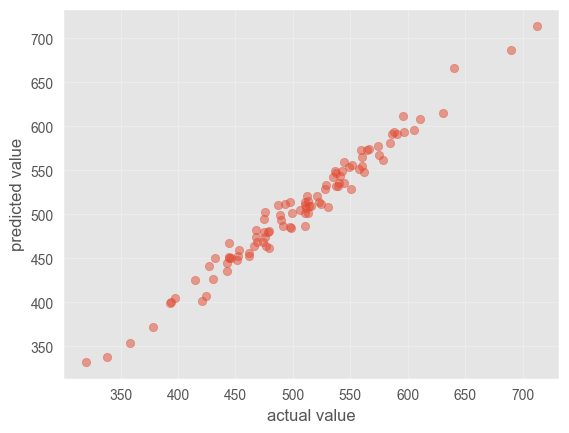

In [153]:
 plt.scatter(y_test, y_pred,alpha=0.5)
 plt.xlabel("actual value")
 plt.ylabel("predicted value")
 plt.grid(True, alpha=0.3)
 plt.show()

# 9. Evaluate Linear Regression

In [154]:
import math
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)
RMSE = math.sqrt(mean_squared_error(y_test, y_pred))

print("MSE:",MSE)
print("MAE:",MAE)
print("R2:",R2)
print("RMSE:",RMSE)

MSE: 114.78370891497588
MAE: 8.482666428876454
R2: 0.9754693642323049
RMSE: 10.713715924690923


# 10. GridSearchCV for Linear Regression

In [155]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(ridge, params, cv=5, scoring="r2")
grid_ridge.fit(X_train, y_train)

best_lr = grid_ridge.best_estimator_

# Print best alpha and results
print("Best Parameters:", grid_ridge.best_params_)
print("Best Alpha:", grid_ridge.best_params_["alpha"])
print("Best R2 Score:", grid_ridge.best_score_)

Best Parameters: {'alpha': 1}
Best Alpha: 1
Best R2 Score: 0.9822076823501643


# 11. Training Decision Tree Model

In [156]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    max_depth=5,          # controls overfitting
    min_samples_split=10,
    random_state=42
)

In [157]:
tree_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [158]:
y_pred = tree_model.predict(X_test)

# 12. Evaluate Decision tree Model

In [159]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 1009.6876076633804
MAE: 25.981033810846505
R2: 0.7842178199600388


# 13. GridSearchCV for Decision Tree

In [160]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeRegressor(random_state=42)

params = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_tree = GridSearchCV(tree, params, cv=5, scoring="r2")
grid_tree.fit(X_train, y_train)

best_tree = grid_tree.best_estimator_

# ✅ Print best parameters
print("Best Parameters:", grid_tree.best_params_)
print("Best R2 Score:", grid_tree.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best R2 Score: 0.8453623806402506


# 14. Linear Regression Vs Decision Tree

In [161]:
  from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))
    print("RMSE:", math.sqrt(mean_squared_error(y_test, y_pred)))

print("=== Ridge Regression ===")
evaluate(best_lr, X_test, y_test)

print("\n=== Decision Tree ===")
evaluate(best_tree, X_test, y_test)

=== Ridge Regression ===
MSE: 113.9896345718116
MAE: 8.479927848857404
R2: 0.9756390673083666
RMSE: 10.676592835348345

=== Decision Tree ===
MSE: 662.5306717164087
MAE: 20.921282307193206
R2: 0.8584093618647554
RMSE: 25.739671165661942
